# *Diabetes Prediction using ML.*

***Required Dependencies for Projects***

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE


import warnings
warnings.filterwarnings('ignore')

***Load Dataset***

In [2]:
data = pd.read_csv("diabetes.csv")

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



***Statistical Measures.***

In [3]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns:
    data[column] = data[column].replace(0, data[column].median())

data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


***Data Standardization.***

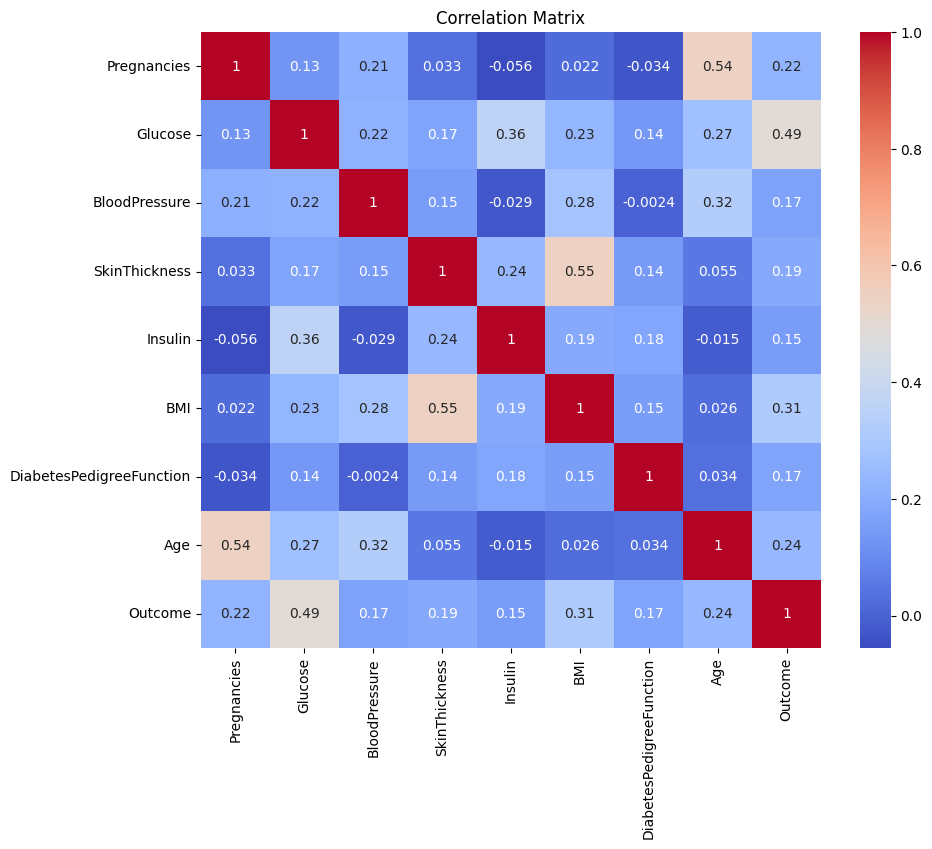

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

***Data Splitting for Training and Testing***


In [7]:
from imblearn.over_sampling import SMOTE

# Features and Target
X = data.drop("Outcome", axis=1)
Y = data["Outcome"]

# Train-Test Split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)

Xtrain, Ytrain = smote.fit_resample(Xtrain, Ytrain)

print("Class distribution after SMOTE:")
print(Ytrain.value_counts())

Class distribution after SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


***Model Evaluation***

***Accuracy Score***

In [15]:
classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

classifier.fit(Xtrain, Ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [16]:
train_prediction = classifier.predict(Xtrain)

train_accuracy = accuracy_score(Ytrain, train_prediction)

print("Training Accuracy :", round(train_accuracy*100,2),"%")

Training Accuracy : 84.5 %


In [17]:
test_prediction = classifier.predict(Xtest)

test_accuracy = accuracy_score(Ytest, test_prediction)

print("Testing Accuracy :", round(test_accuracy*100,2),"%")

Testing Accuracy : 75.32 %


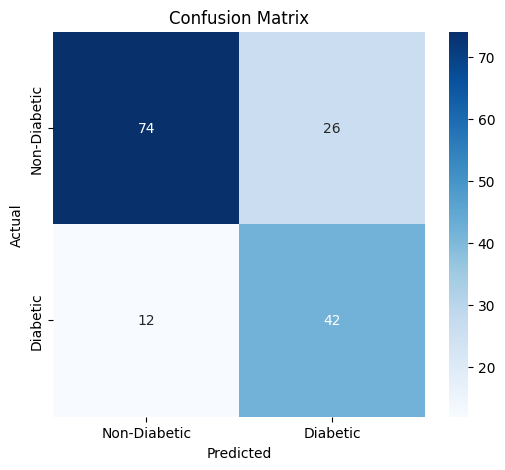

              precision    recall  f1-score   support

           0       0.86      0.74      0.80       100
           1       0.62      0.78      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154



In [18]:
cm = confusion_matrix(Ytest, test_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic","Diabetic"],
    yticklabels=["Non-Diabetic","Diabetic"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(Ytest, test_prediction))

***Predictive Model***

In [19]:
scores = cross_val_score(
    classifier,
    X,
    Y,
    cv=10,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Average Accuracy: {:.2f}%".format(scores.mean() * 100))

Cross Validation Scores: [0.77922078 0.75324675 0.79220779 0.68831169 0.7012987  0.80519481
 0.77922078 0.84415584 0.68421053 0.81578947]
Average Accuracy: 76.43%


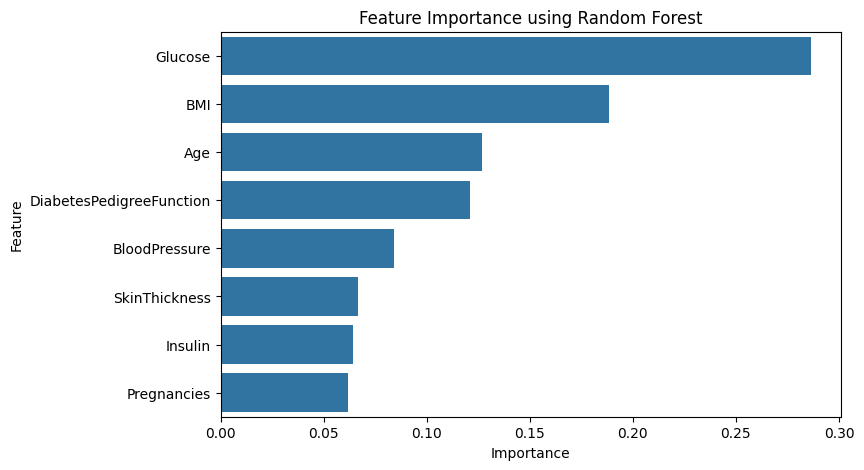

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance using Random Forest")

plt.show()

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(Xtrain, Ytrain)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

Best Parameters: {'bootstrap': True, 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best Cross Validation Accuracy: 79.25%


In [ ]:
classifier = grid_search.best_estimator_

classifier.fit(Xtrain, Ytrain)
from sklearn.metrics import accuracy_score

train_prediction = classifier.predict(Xtrain)

training_accuracy = accuracy_score(Ytrain, train_prediction)

print("Training Accuracy : {:.2f}%".format(training_accuracy * 100))

test_prediction = classifier.predict(Xtest)

testing_accuracy = accuracy_score(Ytest, test_prediction)

print("Testing Accuracy : {:.2f}%".format(testing_accuracy * 100))


Training Accuracy : 88.50%


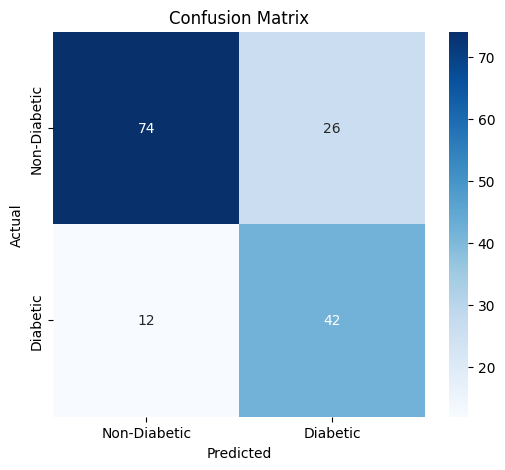

In [25]:
from sklearn.metrics import classification_report

print(classification_report(Ytest, test_prediction))

              precision    recall  f1-score   support

           0       0.86      0.74      0.80       100
           1       0.62      0.78      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154



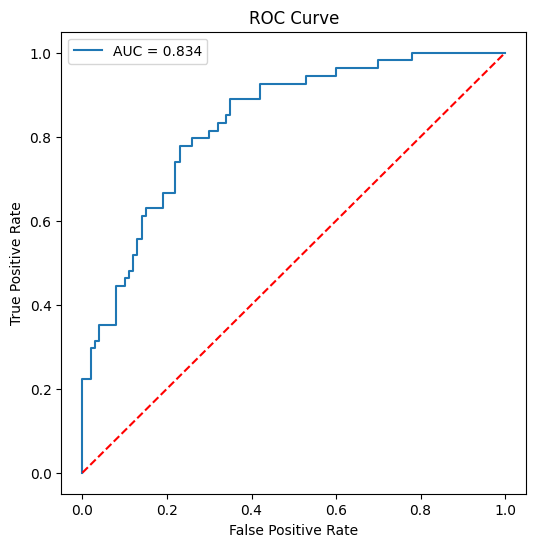

In [26]:
from sklearn.metrics import roc_curve, auc

probability = classifier.predict_proba(Xtest)[:,1]

fpr, tpr, thresholds = roc_curve(Ytest, probability)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="AUC = {:.3f}".format(roc_auc))
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    classifier,
    X,
    Y,
    cv=10,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(scores)

print("Average Cross Validation Accuracy: {:.2f}%".format(scores.mean()*100))

Cross Validation Scores:
[0.75324675 0.80519481 0.77922078 0.67532468 0.71428571 0.80519481
 0.79220779 0.85714286 0.68421053 0.81578947]
Average Cross Validation Accuracy: 76.82%
